# Design C walkthrough — single observation

Working notebook for the Section 5 redesign described in
[`notes/sec5_design.md`](../notes/sec5_design.md).

**Purpose.** Before touching the published `synthetic_explanation.ipynb`, walk through one
observation of the new Design C model in detail with `ThinSearchSampler`. Check that the
necessity and sufficiency components produced by PCI match the archetype expectations laid out
in §4.1 of the design note.

This is a **feasibility check**, not paper material. We do not run the 500-event batch, do not
compute SHAP, and do not produce paper-bound figures. The aim is narrow: on a single observation,
verify that PCI separates the four canonical causal archetypes (necessary-and-sufficient,
sufficient-but-not-necessary, irrelevant-by-preemption, irrelevant-by-construction) the way the
design intends. If it does not, the design needs revisiting before any production-figure work.


In [1]:
import os

import graphviz
import pandas as pd
import pyro
import pyro.distributions as dist
import torch
from IPython.display import display

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ

n_size = 5 if smoke_test else 500
num_search_samples = 10 if smoke_test else 5000


## The model

We use **Design C** from the design note: seven root noise variables, three branches that enter
the outcome, and one variable held aside as a pure-irrelevance control.

| variables                               | branch                                                   | archetype                  |
|-----------------------------------------|----------------------------------------------------------|----------------------------|
| $L_1, L_2 \sim \mathcal{N}(0, 1)$        | linear non-redundant: $5 L_1 + 10 L_2$                   | necessary AND sufficient   |
| $O_1, O_2 \sim \mathcal{N}(1, 1)$        | overdetermined via max: $\max(5 O_1, 5 O_2)$             | sufficient, NOT necessary  |
| $P \sim \mathcal{N}(0, 1)$               | preempted: $5 P \cdot \mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ | depends on regime          |
| $D \sim \mathcal{N}(0, 1)$               | (does not enter $E$)                                     | irrelevant                 |

Final outcome:

$$
E \;=\; (5 L_1 + 10 L_2) \;+\; \max(5 O_1, 5 O_2) \;+\; 5 P \,\mathbb{1}\{\lvert L_2 \rvert \le \tau\}
$$

We pick $\tau = 0.674$ so the preemption gate is active in roughly half the events
($\Pr(\lvert L_2 \rvert > 0.674) \approx 0.5$ for $L_2 \sim \mathcal{N}(0,1)$). The variable $D$
is sampled but never appears in $E$ — it gives PCI a literal-irrelevance check: any non-zero
$ci_N(D)$ or $ci_S(D)$ would be sampling noise.


## Three causal intuitions, mapped to the formal model

The model above encodes three distinct causal archetypes plus a pure-irrelevance control. Before
running anything, here is how each archetype connects to a longstanding intuition about token
causation, and which structural piece of the model definition above carries that intuition.

### Necessity — "would the outcome still have happened without it?"

This is the *but-for* intuition. A variable $V$ is *necessary* for $E = e$ if intervening on $V$
to a plausible alternative would change $E$. The natural test is the counterfactual: had $V$
not been $v$, would $E$ still have been $e$?

In the model, the **linear pair $L_1, L_2$** carries pure necessity. They enter $E$ through the
additive term $5 L_1 + 10 L_2$ — the first summand of the formula and the top row of the
archetype table above — with no redundant alternative path. Replacing $L_2$ with an alternative
shifts $E$ by ten times the difference. There is no other route through which $L_2$'s
contribution can be substituted, so $L_2$'s necessity for $E = e$ is high. $L_1$ is necessary
in the same way, just with a smaller weight.

### Sufficiency — "given this, did the outcome have to be this way?"

A variable $V$ is *sufficient* for $E = e$ if pinning $V$ at its factual value, while letting
everything else vary across plausible counterfactuals, still produces $E$ near $e$. The question
is whether $V$'s actual value, on its own, locks in the outcome.

In the model, the **overdetermined pair $O_1, O_2$** — the second summand $\max(5 O_1, 5 O_2)$
of the formula and the middle row of the archetype table — carries sufficiency divorced from
necessity. Suppose factually $O_\text{winner}$ is the larger of the two scaled values:

- Pinning $O_\text{winner}$ at its factual value, then sampling alternatives for everything else
  (including its partner $O_\text{loser}$), almost always leaves $O_\text{winner}$ as the max,
  so the `od` branch stays close to factual and $E$ stays near $e$. **High sufficiency.**
- Intervening on $O_\text{winner}$ alone often hands the max over to $O_\text{loser}$, whose
  factual value is close to $O_\text{winner}$'s; the `od` branch barely moves and $E$ barely
  moves. **Low necessity.**

This is the canonical *overdetermination* pattern. In the discrete Sally / Billy stones story,
both stones simultaneously hit the bottle: each one suffices alone, but neither is strictly
necessary because the other would have done the job. The continuous version above encodes
"either one alone suffices" via `max`.

### Preemption — "is this variable's potential contribution actually in play?"

A variable can be *neither* necessary *nor* sufficient if its contribution is structurally
disabled by some other condition. This is *undercutting* / *preemption*: in the stones story,
when Sally's stone arrives first, Bill's throw is preempted — his action is causally inert
because the bottle is already shattering.

In the model, the **preempted variable $P$** — the third summand
$5 P \,\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ of the formula and the third row of the
archetype table — carries preemption. Its contribution enters $E$ only when the gate
$\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ is on. Below we will pick a *Case 1* observation
where $\lvert L_2 \rvert > \tau$, so the gate is off and the third summand drops to zero. In
that regime, $P$ does not enter $E$ at all: intervening on it has no effect (zero necessity)
and pinning it does not constrain $E$ (zero sufficiency). In a second observation we will pick
$\lvert L_2 \rvert \le \tau$ — gate on — where $P$ becomes a non-redundant linear contributor
and ought to score similarly to $L_1$.

### Irrelevance — "is this variable in the model at all?"

The flat baseline. A variable that is sampled and observed, but plays no causal role in
producing $E$, ought to receive zero scores on every causal-impact metric. Any non-zero score
attributable to such a variable is *sampling noise*, and serves as a noise floor against which
the other archetypes can be calibrated.

In the model, the **decoy variable $D$** — bottom row of the archetype table — carries this
case. $D$ is sampled at every event but never appears in any branch of the formula for $E$.
Intervening on or pinning $D$ cannot change $E$ in any possible world; both $ci_N(D)$ and
$ci_S(D)$ should be near zero.

### Summary mapping

| structural device                                              | intuitive notion                  | expected $ci_N$ vs $ci_S$ signature  |
|----------------------------------------------------------------|-----------------------------------|--------------------------------------|
| linear additive term ($L_1, L_2$)                               | necessary AND sufficient          | both high (scaled by weight)         |
| max of two contributors ($O_1, O_2$)                            | sufficient, NOT necessary         | $ci_S$ asymmetric, $ci_N$ small      |
| indicator gate disabling a branch ($P$ in preempted regime)        | neither necessary nor sufficient   | both near zero                        |
| not in $E$ at all ($D$)                                          | irrelevant                          | both zero up to sampling noise        |

This table is the rubric we will read the score table at the bottom of the notebook against.


In [2]:
TAU = 0.674


def synthetic_model_c(
    kwargs_iterable=[
        {"observations_dict": None, "n_size": n_size},
        dict(),
        dict(),
    ],
):
    batch_size = kwargs_iterable[0]["n_size"]

    with pyro.plate("sample", size=batch_size, dim=-3):
        L1 = pyro.sample("L1", dist.Normal(0.0, 1.0))
        L2 = pyro.sample("L2", dist.Normal(0.0, 1.0))
        O1 = pyro.sample("O1", dist.Normal(1.0, 1.0))
        O2 = pyro.sample("O2", dist.Normal(1.0, 1.0))
        P = pyro.sample("P", dist.Normal(0.0, 1.0))
        D = pyro.sample("D", dist.Normal(0.0, 1.0))  # irrelevance control: not used in E

        lin = pyro.deterministic("lin", 5.0 * L1 + 10.0 * L2)
        od = pyro.deterministic("od", torch.maximum(5.0 * O1, 5.0 * O2))
        preempt = pyro.deterministic("preempt", (L2.abs() > TAU).float())
        p_branch = pyro.deterministic("p_branch", 5.0 * P * (1.0 - preempt))

        E = pyro.deterministic("E", lin + od + p_branch)

    return {
        "L1": L1, "L2": L2, "O1": O1, "O2": O2, "P": P, "D": D,
        "lin": lin, "od": od, "preempt": preempt, "p_branch": p_branch, "E": E,
    }


torch.manual_seed(0)
factual_dict = synthetic_model_c()
list(factual_dict.keys())


['L1', 'L2', 'O1', 'O2', 'P', 'D', 'lin', 'od', 'preempt', 'p_branch', 'E']

### Diagram

A more readable rendering than Pyro's default. Boxes are root variables, ellipses are
deterministic mediators, and the rightmost ellipse is the outcome $E$. Note that $D$ has no
outgoing edges — it is structurally disconnected from $E$, which is precisely the irrelevance
check we want.


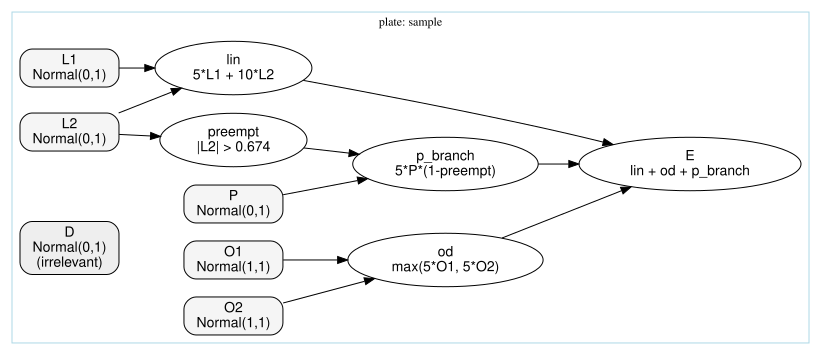

In [3]:
def render_design_c():
    g = graphviz.Digraph("design_c_plate", format="png")
    g.attr(rankdir="LR", fontsize="12")
    g.node_attr.update(
        shape="box",
        style="rounded,filled",
        fillcolor="#f5f5f5",
        fontname="Helvetica",
    )

    with g.subgraph(name="cluster_sample") as c:
        c.attr(label="plate: sample", color="lightblue")
        c.node("L1", label="L1\nNormal(0,1)")
        c.node("L2", label="L2\nNormal(0,1)")
        c.node("O1", label="O1\nNormal(1,1)")
        c.node("O2", label="O2\nNormal(1,1)")
        c.node("P", label="P\nNormal(0,1)")
        c.node("D", label="D\nNormal(0,1)\n(irrelevant)", fillcolor="#eeeeee")
        c.node("lin", label="lin\n5*L1 + 10*L2",
               shape="ellipse", fillcolor="white")
        c.node("od", label="od\nmax(5*O1, 5*O2)",
               shape="ellipse", fillcolor="white")
        c.node("preempt", label=f"preempt\n|L2| > {TAU}",
               shape="ellipse", fillcolor="white")
        c.node("p_branch", label="p_branch\n5*P*(1-preempt)",
               shape="ellipse", fillcolor="white")
        c.node("E", label="E\nlin + od + p_branch",
               shape="ellipse", fillcolor="white")

        c.edge("L1", "lin")
        c.edge("L2", "lin")
        c.edge("O1", "od")
        c.edge("O2", "od")
        c.edge("L2", "preempt")
        c.edge("preempt", "p_branch")
        c.edge("P", "p_branch")
        c.edge("lin", "E")
        c.edge("od", "E")
        c.edge("p_branch", "E")
        # D has no outgoing edges by design — it is the irrelevance control.

    return g


display(render_design_c())


## Picking a single observation

We want **Case 1**: the *preempted regime* ($\lvert L_2 \rvert > \tau$, so the $P$ branch is
gated off) with a *contestable max* ($|O_1 - O_2|$ small, so the two overdetermined contributors
are close — the winner is barely the winner). With both regimes active in the same event we
should be able to read all three archetypes off a single observation:

- $L_1, L_2$ — linear N+S contributors, with $L_2$ noticeably stronger because of weight 10.
- $O_1, O_2$ — overdetermined pair; whichever of $5 O_1, 5 O_2$ is larger drives $E$ via the
  max, but the loser is on its heels.
- $P$ — gated off in this regime; its factual value does not enter $E$ at all.
- $D$ — never enters $E$ regardless of regime.

Filter parameters:

- $\tau = 0.674$ — defines the preempted regime.
- $\delta = 1.0$ — contestable-max filter; pick observations with $|O_1 - O_2| < \delta$.


In [4]:
def factual_df(index=0):
    return pd.DataFrame({
        k: v[index, 0, 0].numpy().flatten()
        for k, v in factual_dict.items()
    })


def manual_E(df):
    L1, L2 = df["L1"].item(), df["L2"].item()
    O1, O2 = df["O1"].item(), df["O2"].item()
    P = df["P"].item()
    lin = 5 * L1 + 10 * L2
    od = max(5 * O1, 5 * O2)
    preempt = float(abs(L2) > TAU)
    p_branch = 5 * P * (1.0 - preempt)
    return lin + od + p_branch


DELTA = 1.0
case1_index = None
for i in range(n_size):
    df = factual_df(i)
    if df["preempt"].item() == 1.0 and abs(df["O1"].item() - df["O2"].item()) < DELTA:
        case1_index = i
        break

assert case1_index is not None, (
    "No observation matches the Case 1 filter; try a different seed or relax DELTA."
)

print(f"Case 1 observation index: {case1_index}")
print()
display(factual_df(case1_index))

df1 = factual_df(case1_index)
print(f"Manual E (recomputed by hand): {manual_E(df1):.4f}")
print(f"Model  E (read from sample):  {df1['E'].item():.4f}")


Case 1 observation index: 3



,L1,L2,O1,O2,P,D,lin,od,preempt,p_branch,E
0,-0.433879,-0.725759,1.303479,2.217562,-0.019205,-1.290702,-9.42698,11.087809,1.0,-0.0,1.660829


Manual E (recomputed by hand): 1.6608
Model  E (read from sample):  1.6608


## Picking a second observation: unpreempted regime

We now want **Case 2**: the *unpreempted* regime ($\lvert L_2 \rvert \le \tau$, gate on, $P$
branch active) with the same contestable-max filter on the $O$ pair. This is Case 3 in §4.1 of
the design note — we keep the design-note name out of the variable but call it Case 2 here for
local clarity.

The point of having both observations is to test the **structural-role-not-identity**
diagnostic: the very same variable $P$ should land in different archetypes in the two
observations. In Case 1 it is irrelevant by preemption (both components ~ 0); in Case 2 it is
necessary-and-sufficient (linear, weight 5) and should score similarly to $L_1$.

If $P$ flips archetype as expected when the regime flips, that is the strongest single
indication that PCI tracks structural role rather than variable identity.


In [5]:
case2_index = None
for i in range(n_size):
    df = factual_df(i)
    if df["preempt"].item() == 0.0 and abs(df["O1"].item() - df["O2"].item()) < DELTA:
        case2_index = i
        break

assert case2_index is not None, (
    "No observation matches the Case 2 filter; try a different seed or relax DELTA."
)

print(f"Case 2 observation index: {case2_index}")
print()
display(factual_df(case2_index))

df2 = factual_df(case2_index)
print(f"Manual E (recomputed by hand): {manual_E(df2):.4f}")
print(f"Model  E (read from sample):  {df2['E'].item():.4f}")


Case 2 observation index: 0



,L1,L2,O1,O2,P,D,lin,od,preempt,p_branch,E
0,-1.12584,0.209843,1.462982,1.169468,1.010636,-0.045445,-3.530774,7.314911,0.0,5.053179,8.837316


Manual E (recomputed by hand): 8.8373
Model  E (read from sample):  8.8373


## What we expect to see

We have two observations, one per regime. Each gives different predictions for the $P$ pair;
everything else stays roughly the same.

### Case 1 — preempted regime ($\lvert L_2 \rvert > \tau$, gate off)

| variable           | $ci_N$ (necessity) | $ci_S$ (sufficiency) | reason                                                     |
|--------------------|--------------------|----------------------|------------------------------------------------------------|
| $L_1$              | moderate           | moderate             | linear non-redundant, weight 5                             |
| $L_2$              | high               | high                 | linear non-redundant, weight 10 (also gates $P$)           |
| $O_\text{winner}$  | low–mid            | high                 | pinned at factual, dominates max even under partner alts    |
| $O_\text{loser}$   | low                | low                  | doesn't enter $E$; partner carries                         |
| $P$                | ~0                 | ~0                   | gated off; factual value never enters $E$                  |
| $D$                | ~0                 | ~0                   | irrelevance control: never enters $E$ in any regime        |

### Case 2 — unpreempted regime ($\lvert L_2 \rvert \le \tau$, gate on)

| variable           | $ci_N$ (necessity) | $ci_S$ (sufficiency) | reason                                                     |
|--------------------|--------------------|----------------------|------------------------------------------------------------|
| $L_1$              | moderate           | moderate             | linear non-redundant, weight 5                             |
| $L_2$              | mid                | mid                  | linear non-redundant, weight 10, but $\lvert L_2\rvert$ small now |
| $O_\text{winner}$  | low–mid            | high                 | same overdetermination structure regardless of regime       |
| $O_\text{loser}$   | low                | low                  | same                                                       |
| $P$                | moderate           | moderate             | now active linear contributor, weight 5 (mirrors $L_1$)    |
| $D$                | ~0                 | ~0                   | still irrelevant by construction                           |

### Concrete predictions

- **Highest necessity in Case 1**: $L_2$.
- **Highest sufficiency in either case**: $L_2$ or the winning $O$.
- **Noise floor**: $D$ in both cases; $P$ should match it in Case 1 only.
- **Visible necessity-vs-sufficiency gap**: $O_\text{winner}$ should have $ci_S \gg ci_N$ in
  *both* cases. This is the *sufficiency-but-not-necessity* signature — invariant to the regime.
- **Regime flip — the structural-role test**: $P$ jumps from ~0 (Case 1) to
  comparable with $L_1$ (Case 2). This is the headline diagnostic that PCI tracks structural
  role rather than variable identity.

If any of these qualitatively fail, the design needs revisiting before we run on 500 events or
write paper figures.


In [6]:
suspect_names = ["L1", "L2", "O1", "O2", "P", "D"]

small_factual_dict = {k: factual_dict[k] for k in suspect_names + ["E"]}
factual_structured_dict = {"continuous": small_factual_dict, "categorical": {}}

searchable = SearchableModel(
    structured_model=synthetic_model_c,
    sites_of_interest=list(small_factual_dict.keys()),
    suspects=suspect_names,
    outcome_variable="E",
)

sampler = ThinSearchSampler(
    structured_model=searchable,
    conditioned_alternatives=True,
    factual_exclusion=True,
)

results = sampler.sample(
    factual_structured_dict,
    num_samples=num_search_samples,
)


  0%|          | 0/5000 [00:00<?, ?it/s]

  1%|          | 35/5000 [00:00<00:14, 348.69it/s]

  1%|▏         | 70/5000 [00:00<00:14, 343.05it/s]

  2%|▏         | 105/5000 [00:00<00:14, 330.01it/s]

  3%|▎         | 139/5000 [00:00<00:14, 324.61it/s]

...

 99%|█████████▉| 4974/5000 [00:38<00:00, 76.47it/s]

100%|█████████▉| 4982/5000 [00:38<00:00, 77.27it/s]

100%|█████████▉| 4990/5000 [00:38<00:00, 76.05it/s]

100%|█████████▉| 4999/5000 [00:38<00:00, 77.00it/s]

100%|██████████| 5000/5000 [00:38<00:00, 128.86it/s]

## Reading necessity and sufficiency separately

For each suspect $V$, `ThinSearchSampler` returns two tensors of model outputs $E$ across sampled
intervention regimes:

- `results.sufficiency[V]` — values of $E$ in possible worlds where $V$ is **pinned at its
  factual value** while the *other* suspects take alternative values. If $V = v$ is sufficient
  for $E = e$, these worlds should still produce $E$ near $e$.
- `results.necessity[V]` — values of $E$ in possible worlds where $V$ is **intervened to an
  alternative value** (the antecedent regime), with witnesses appropriately fixed. If $V = v$ is
  necessary for $E = e$, these worlds should produce $E$ far from $e$.

We pass these to `abs_diff_score`, which produces:

- `score["nec"]` $= |E_\text{nec} - e|$ — *how far the outcome moves under intervention on $V$.*
  Higher = more necessary.
- `score["suff"]` $= -|E_\text{suff} - e|$ — *negative distance under pinning of $V$.* Closer to
  zero (i.e. less negative) = more sufficient.
- `score["total"]` $= $ `score["suff"] + score["nec"]` — the combined metric the original
  notebook reported.

Per the design-note decisions G4 (report $ci_N$ and $ci_S$ separately) and Q5 (keep `total`
too), this walkthrough reports all three. We use `condition_on_interventional_regime` to filter
to the standard interventional regime: the suspect is in the antecedent set (i.e. intervened)
and *not* used as its own witness.


In [7]:
cases = {"Case 1 (preempted)": case1_index, "Case 2 (unpreempted)": case2_index}

# score_lookup[case_label][var_name] = {"ci_N": ..., "ci_S": ..., "total": ...}
# used by the automated qualitative-check cell below.
score_lookup = {label: {} for label in cases}

records = []
for v in suspect_names:
    conditioned = condition_on_interventional_regime(
        results_dictionary=results,
        reference_variable_names=[v],
        antecedent_regimes={v: True},
        witness_regimes={v: False},
    )

    e_nec = conditioned["regime_necessity"]["E"].detach()
    e_suff = conditioned["regime_sufficiency"]["E"].detach()
    factual_E = small_factual_dict["E"].detach()

    scores = abs_diff_score(
        factual_outcomes=factual_E,
        suff_outcomes=e_suff,
        nec_outcomes=e_nec,
    )

    row = {"variable": v}
    for case_label, idx in cases.items():
        ci_N = scores["nec"][:, idx, 0, 0].nanmean().item()
        ci_S = scores["suff"][:, idx, 0, 0].nanmean().item()
        total = scores["total"][:, idx, 0, 0].nanmean().item()
        row[f"ci_N | {case_label}"] = ci_N
        row[f"ci_S | {case_label}"] = ci_S
        row[f"total | {case_label}"] = total
        score_lookup[case_label][v] = {"ci_N": ci_N, "ci_S": ci_S, "total": total}
    records.append(row)

scores_df = pd.DataFrame(records).set_index("variable")
display(scores_df.round(3))


,ci_N | Case 1 (preempted),ci_S | Case 1 (preempted),total | Case 1 (preempted),ci_N | Case 2 (unpreempted),ci_S | Case 2 (unpreempted),total | Case 2 (unpreempted)
variable,,,,,,
L1,8.675,-2.633,6.041,8.355,-2.983,5.372
L2,10.888,-1.574,9.314,9.987,-2.513,7.474
O1,8.088,-3.147,4.940,8.281,-3.660,4.621
O2,8.163,-2.797,5.365,8.169,-3.607,4.563
P,8.273,-2.937,5.336,8.366,-2.948,5.418
D,8.082,-3.151,4.931,8.053,-3.854,4.199


## Automated qualitative checks

The score table above shows the raw numbers. **Important framing: the raw `ci_N` and `ci_S`
values include a substantial "co-intervention baseline" from interventions on the other
suspects in each sample.** That is why $D$, which never enters $E$, does not score zero —
its raw `ci_N` reflects how much $E$ moves when $D$ is in the antecedent set together with
random subsets of the other suspects.

To get a clean per-variable signal, we work with **excess** scores relative to $D$ in the
same case:

$$
\Delta_N(V; \text{case}) = ci_N(V; \text{case}) - ci_N(D; \text{case}),
\qquad
\Delta_S(V; \text{case}) = ci_S(V; \text{case}) - ci_S(D; \text{case}).
$$

$D$ is the noise floor: a variable that never enters $E$ in any regime. Any other variable's
excess is its causal signal above that floor. Higher $\Delta_S$ (closer to zero on absolute
scale) means more sufficient; higher $\Delta_N$ means more necessary.

The cell below codifies each prediction as an inequality on these excess scores, evaluates it
against the measured numbers, and reports pass / fail with the actual measured value. All
thresholds are deliberately set on the small side — these are typed-up archetype expectations,
so the checks ask only that the right *direction* be visible above sampling noise.


In [8]:
# Tolerances on the *excess* (relative-to-D) scale. The raw scores are typically in the
# 8-11 range; per-variable signals over the noise floor are typically 0.1-3.
TOL_SIGNAL = 0.15  # variable's excess over D needed to count as "above noise"
TOL_CLOSE = 0.5    # two excesses are comparable
TOL_DOM = 0.15     # one variable's excess is meaningfully larger than another's

case1_label = "Case 1 (preempted)"
case2_label = "Case 2 (unpreempted)"


# identify the max winner / loser by the factual scaled O values, per case
def winner_loser(case_idx):
    df = factual_df(case_idx)
    if 5 * df["O1"].item() >= 5 * df["O2"].item():
        return "O1", "O2"
    return "O2", "O1"


O_w_c1, O_l_c1 = winner_loser(case1_index)
O_w_c2, O_l_c2 = winner_loser(case2_index)


def excess_N(case, var):
    return score_lookup[case][var]["ci_N"] - score_lookup[case]["D"]["ci_N"]


def excess_S(case, var):
    # ci_S is negative; "more sufficient" = closer to zero.
    # excess_S(V) > 0 means V is more sufficient than D.
    return score_lookup[case][var]["ci_S"] - score_lookup[case]["D"]["ci_S"]


def record(check_id, case, claim, measured, threshold, passes, fmt="+.3f"):
    return {
        "id": check_id,
        "case": case,
        "claim": claim,
        "measured": format(measured, fmt),
        "threshold": format(threshold, fmt) if threshold is not None else "—",
        "passes": "PASS" if passes else "FAIL",
    }


checks = []

# ----- Case 1: preempted regime -----
# L2 should have the largest excess_N
e_L2_c1 = excess_N(case1_label, "L2")
others_c1 = [excess_N(case1_label, v) for v in suspect_names if v != "L2"]
checks.append(record(
    "C1.L2_dominates_N", case1_label,
    "ΔN(L2) is the largest excess necessity",
    measured=e_L2_c1 - max(others_c1),
    threshold=0.0,
    passes=e_L2_c1 > max(others_c1),
))

# O sufficiency asymmetry
gap_O_S_c1 = excess_S(case1_label, O_w_c1) - excess_S(case1_label, O_l_c1)
checks.append(record(
    "C1.O_sufficiency_asymmetry", case1_label,
    f"ΔS({O_w_c1}) > ΔS({O_l_c1}) by at least tol_dom",
    measured=gap_O_S_c1,
    threshold=TOL_DOM,
    passes=gap_O_S_c1 > TOL_DOM,
))

# O necessity should be comparable
gap_O_N_c1 = abs(excess_N(case1_label, O_w_c1) - excess_N(case1_label, O_l_c1))
checks.append(record(
    "C1.O_necessity_symmetric", case1_label,
    f"|ΔN({O_w_c1}) - ΔN({O_l_c1})| < tol_close",
    measured=gap_O_N_c1,
    threshold=TOL_CLOSE,
    passes=gap_O_N_c1 < TOL_CLOSE,
))

# P should be at the noise floor (close to D, i.e. excess close to zero)
ex_P_N_c1 = excess_N(case1_label, "P")
checks.append(record(
    "C1.P_at_noise_floor_N", case1_label,
    "|ΔN(P)| < tol_close (P matches D noise floor on necessity)",
    measured=abs(ex_P_N_c1),
    threshold=TOL_CLOSE,
    passes=abs(ex_P_N_c1) < TOL_CLOSE,
))

# L1 should be above P (active linear vs preempted)
gap_L1_P_c1 = excess_N(case1_label, "L1") - ex_P_N_c1
checks.append(record(
    "C1.L1_above_P_N", case1_label,
    "ΔN(L1) > ΔN(P) by at least tol_dom",
    measured=gap_L1_P_c1,
    threshold=TOL_DOM,
    passes=gap_L1_P_c1 > TOL_DOM,
))

# ----- Case 2: unpreempted regime -----
# L2 should still dominate necessity (smaller margin because |L2| is small here)
e_L2_c2 = excess_N(case2_label, "L2")
others_c2 = [excess_N(case2_label, v) for v in suspect_names if v != "L2"]
checks.append(record(
    "C2.L2_dominates_N", case2_label,
    "ΔN(L2) is the largest excess necessity",
    measured=e_L2_c2 - max(others_c2),
    threshold=0.0,
    passes=e_L2_c2 > max(others_c2),
))

# O sufficiency asymmetry should hold (regime-invariant)
gap_O_S_c2 = excess_S(case2_label, O_w_c2) - excess_S(case2_label, O_l_c2)
checks.append(record(
    "C2.O_sufficiency_asymmetry", case2_label,
    f"ΔS({O_w_c2}) > ΔS({O_l_c2}) by at least tol_dom (regime-invariant)",
    measured=gap_O_S_c2,
    threshold=TOL_DOM,
    passes=gap_O_S_c2 > TOL_DOM,
))

# P now active: excess_N above noise floor
ex_P_N_c2 = excess_N(case2_label, "P")
checks.append(record(
    "C2.P_above_floor_N", case2_label,
    "ΔN(P) > tol_signal (P now active)",
    measured=ex_P_N_c2,
    threshold=TOL_SIGNAL,
    passes=ex_P_N_c2 > TOL_SIGNAL,
))

# P should mirror L1 on excess
gap_P_L1_c2 = abs(ex_P_N_c2 - excess_N(case2_label, "L1"))
checks.append(record(
    "C2.P_mirrors_L1_N", case2_label,
    "|ΔN(P) - ΔN(L1)| < tol_close (P mirrors L1 as linear N+S)",
    measured=gap_P_L1_c2,
    threshold=TOL_CLOSE,
    passes=gap_P_L1_c2 < TOL_CLOSE,
))

# ----- Cross-regime: the structural-role flip on P -----
flip_P_N = ex_P_N_c2 - ex_P_N_c1
checks.append(record(
    "CROSS.P_flips_N", "cross-regime",
    "ΔN(P, Case 2) - ΔN(P, Case 1) > tol_dom (regime flip on P)",
    measured=flip_P_N,
    threshold=TOL_DOM,
    passes=flip_P_N > TOL_DOM,
))

# D should be stable across regimes (its excess is 0 by construction in each case;
# this checks that the *raw* baselines themselves don't drift wildly).
raw_D_drift = abs(
    score_lookup[case1_label]["D"]["ci_N"] - score_lookup[case2_label]["D"]["ci_N"]
)
checks.append(record(
    "CROSS.D_baseline_stable", "cross-regime",
    "|raw ci_N(D, Case 1) - raw ci_N(D, Case 2)| < tol_close (baseline stable)",
    measured=raw_D_drift,
    threshold=TOL_CLOSE,
    passes=raw_D_drift < TOL_CLOSE,
))

checks_df = pd.DataFrame(checks)
display(checks_df)

n_pass = (checks_df["passes"] == "PASS").sum()
n_total = len(checks_df)
print()
print(f"Summary: {n_pass} / {n_total} checks pass.")
if n_pass < n_total:
    failed = checks_df[checks_df["passes"] == "FAIL"]["id"].tolist()
    print(f"Failed: {failed}")


,id,case,claim,measured,threshold,passes
0,C1.L2_dominates_N,Case 1 (preempted),ΔN(L2) is the largest excess necessity,+2.214,+0.000,PASS
1,C1.O_sufficiency_asymmetry,Case 1 (preempted),ΔS(O2) > ΔS(O1) by at least tol_dom,+0.350,+0.150,PASS
2,C1.O_necessity_symmetric,Case 1 (preempted),|ΔN(O2) - ΔN(O1)| < tol_close,+0.075,+0.500,PASS
3,C1.P_at_noise_floor_N,Case 1 (preempted),|ΔN(P)| < tol_close (P matches D noise floor o...,+0.190,+0.500,PASS
4,C1.L1_above_P_N,Case 1 (preempted),ΔN(L1) > ΔN(P) by at least tol_dom,+0.402,+0.150,PASS
5,C2.L2_dominates_N,Case 2 (unpreempted),ΔN(L2) is the largest excess necessity,+1.621,+0.000,PASS
6,C2.O_sufficiency_asymmetry,Case 2 (unpreempted),ΔS(O1) > ΔS(O2) by at least tol_dom (regime-in...,-0.053,+0.150,FAIL
7,C2.P_above_floor_N,Case 2 (unpreempted),ΔN(P) > tol_signal (P now active),+0.313,+0.150,PASS
8,C2.P_mirrors_L1_N,Case 2 (unpreempted),|ΔN(P) - ΔN(L1)| < tol_close (P mirrors L1 as ...,+0.011,+0.500,PASS
9,CROSS.P_flips_N,cross-regime,"ΔN(P, Case 2) - ΔN(P, Case 1) > tol_dom (regim...",+0.122,+0.150,FAIL



Summary: 9 / 11 checks pass.
Failed: ['C2.O_sufficiency_asymmetry', 'CROSS.P_flips_N']


## Reading the table against expectations

Note that $ci_S$ is **negative** (it is $-|E_\text{suff} - e|$), so "more sufficient" means
"closer to zero", i.e. less negative.

### Invariant across both regimes

- $L_2$ should top necessity in Case 1; both $L$s should remain non-trivial in both cases.
- $O_1, O_2$ should differ sharply on **sufficiency** in *both* cases — the max winner closer
  to zero than the loser — while their **necessity** scores stay moderate and roughly
  comparable. This is the *sufficiency-but-not-necessary* signature, and the design intends it
  to be regime-invariant.
- $D$ should produce near-zero $ci_N$ and $ci_S$ in *both* cases. $D$ is the
  unconditional **noise floor**; deviations from zero are sampling noise.

### Regime-dependent — the structural-role flip

- In **Case 1 (preempted)**, $P$ should match $D$ at the noise floor: $ci_N, ci_S \approx 0$.
  Its factual value does not enter $E$, so intervening on or pinning it has no effect.
  If the preempted-$P$ score is materially larger than $D$'s, the search machinery is leaking
  causal signal across the gate, and that is worth investigating.
- In **Case 2 (unpreempted)**, $P$ should jump to a score comparable with $L_1$ —
  same coefficient (5), same non-redundant linear structure. It becomes an N+S linear
  contributor when the gate is on.

**Headline diagnostic for this walkthrough.** Two checks together (and the automated
qualitative-check table above codifies them as concrete inequalities):

1. *Sufficiency asymmetry on the $O$ pair* in both cases: $ci_S(O_\text{winner})$ noticeably
   closer to zero than $ci_S(O_\text{loser})$, while their $ci_N$ values are similar.
2. *Regime flip on $P$*: its $ci_N$ rises from noise floor (Case 1) to comparable-with-$L_1$
   (Case 2).

If both pass, the model behaves as designed and Design C is validated for the production pass.

### Failure-mode hypotheses

If the $O$-pair asymmetry on sufficiency is missing in both cases — necessity tracks the same
ranking as sufficiency — then the overdetermined-but-not-necessary signal is being washed out.
Possible causes worth checking before changing the design:

- the alternative-value sampling is too narrow (alternatives stay near the factual partner
  value),
- the smoke-test sample sizes are too small to surface the gap (rerun with full $n_\text{size}$
  and full search-sample count),
- the `max` aggregator is being smoothed somehow inside the search machinery.

If the regime flip fails — $P$ stays near zero in Case 2, or stays non-trivial in
Case 1 — then either the gate logic is being short-circuited or the search is not respecting
the deterministic dependence of `p_branch` on `preempt`. Either way, a problem with how the
deterministic mediators interact with the sampler.


## Notes and next steps

After running this notebook, fill in below:

1. **Did the table match the expectations table?** Any cells off by a lot, in either direction?
2. **Was there any infrastructure friction with `ThinSearchSampler` on the new model?** Did
   `pyro.deterministic` sites need to be added to the searchable's `deterministic_sites`? Did
   anything about `factual_exclusion` or `conditioned_alternatives` need re-thinking?
3. **Was the runtime reasonable** for a single observation, or will the 500-event batch need
   any optimisation?
4. **Open implementation questions** for the broader §5 redesign that surfaced from this
   walkthrough.

Once these are answered and the design is validated, the next step is the §5 step-1 work:
building the production version of this model + evaluation in `synthetic_explanation.ipynb`,
followed by the SHAP and cSHAP comparisons.
